# Lab 5 — The Wireless Channel: Path Loss, Multipath, Fading and Doppler

**Companion to Chapter 11** (*The Wireless Channel*).
**Time needed:** about 75 minutes. **Difficulty:** core.

The wireless channel is the adversary every other chapter is fighting. It attenuates
(path loss), it shadows (buildings, hills, bodies), it echoes (multipath delay spread) and
it moves (Doppler). This lab separates those effects by scale, generates each with the
models used in 3GPP evaluations, verifies their statistics against theory, and measures what
fading does to the error rate.

### What you will learn
1. Separate the three scales of propagation: path loss, shadowing and small-scale fading.
2. Compute a link budget and explain the two-ray breakpoint.
3. Generate Rayleigh fading with the Clarke/Jakes Doppler spectrum and verify its envelope
   distribution, autocorrelation, level-crossing rate and average fade duration.
4. Relate delay spread to coherence bandwidth, and Doppler to coherence time.
5. Measure the cost of fading on BER (the motivation for diversity and coding), and sound a channel.

### Prerequisites
Lab 2 (BER in AWGN). Random processes, autocorrelation and PSD (Chapter 3).

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Large scale: path loss, two-ray, shadowing, link budget | |
| 2 | Small scale: the Rayleigh envelope and Doppler | |
| 3 | Level crossings and fade durations | |
| 4 | Frequency selectivity: tapped-delay-line models | yes |
| 5 | Coherence bandwidth, measured | |
| 6 | The price of fading | |
| 7 | Channel sounding by correlation | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=5, lab="05")
c0 = 299_792_458.0

Lab 05 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 5


## 1. Large scale: path loss, two-ray, shadowing and the link budget

In free space the received power falls as $1/d^2$ (Friis):
$\mathrm{FSPL} = 20\log_{10}(4\pi d f/c)$ dB. Over flat ground, the direct ray and the
ground-reflected ray interfere; beyond the **breakpoint** $d_b \approx 4h_th_r/\lambda$ they
cancel more and more and the power falls as $1/d^4$ (40 dB/decade). Real environments sit in
between, which the **log-distance model** captures with an exponent $n$ (2 in free space,
2.7–3.5 urban, 4+ through walls) plus **log-normal shadowing** $X_\sigma$ with $\sigma$ = 4–10 dB.

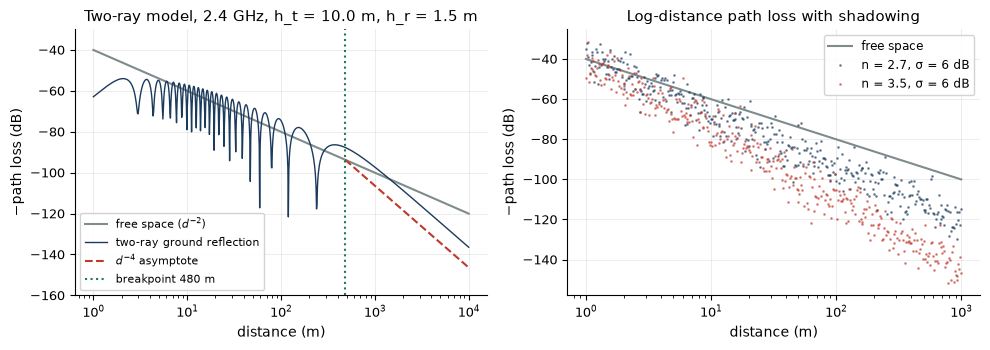

In [3]:
fc = 2.4e9
lam = c0 / fc
ht, hr = 10.0, 1.5
d = np.logspace(0, 4, 800)
r_los = np.sqrt(d ** 2 + (ht - hr) ** 2)
r_ref = np.sqrt(d ** 2 + (ht + hr) ** 2)
field = (np.exp(-2j * np.pi * r_los / lam) / r_los - np.exp(-2j * np.pi * r_ref / lam) / r_ref)  # Γ = -1
pl_2ray = -lk.db((lam / (4 * np.pi)) ** 2 * np.abs(field) ** 2)
db_ = 4 * ht * hr / lam
f, ax = lk.fig("row2", 1, 2)
ax[0].semilogx(d, -cl.fspl_db(d, fc), color=lk.GRAY, label="free space ($d^{-2}$)")
ax[0].semilogx(d, -pl_2ray, color=lk.NAVY, lw=1, label="two-ray ground reflection")
ax[0].semilogx(d[d > db_], -cl.fspl_db(db_, fc) - 40 * np.log10(d[d > db_] / db_), color=lk.RED, ls="--",
               label="$d^{-4}$ asymptote")
ax[0].axvline(db_, color=lk.GREEN, ls=":", label=f"breakpoint {db_:.0f} m")
ax[0].set_ylim(-160, -30); ax[0].set_xlabel("distance (m)"); ax[0].set_ylabel("−path loss (dB)")
ax[0].legend(fontsize=8); ax[0].set_title(f"Two-ray model, 2.4 GHz, h_t = {ht} m, h_r = {hr} m")
d2 = np.logspace(0, 3, 400)
ax[1].semilogx(d2, -cl.fspl_db(d2, fc), color=lk.GRAY, label="free space")
for n_, col in [(2.7, lk.NAVY), (3.5, lk.RED)]:
    ax[1].semilogx(d2, -cl.log_distance_pl_db(d2, fc, n=n_, sigma_db=6, rng=rng), ".", ms=2, alpha=0.5,
                   color=col, label=f"n = {n_}, σ = 6 dB")
ax[1].set_xlabel("distance (m)"); ax[1].set_ylabel("−path loss (dB)"); ax[1].legend()
ax[1].set_title("Log-distance path loss with shadowing")
lk.show(f)

**What you should see.** Left: close in, the two rays beat against each other (deep nulls);
beyond about 480 m the two-ray loss bends onto the red 40 dB/decade line. Right: shadowing
scatters measurements ±6 dB around the mean; a link designed for the *mean* would fail half
the time at the cell edge, which is why link budgets carry a shadowing margin.

### A link budget
Received power $P_r = P_t + G_t + G_r - L_{\text{path}} - L_{\text{misc}}$ (dB units); the link closes if
$P_r - (-174 + 10\log_{10}B + \mathrm{NF}) \ge \mathrm{SNR}_{\text{req}} + \text{margins}$.

In [5]:
def link_budget(ptx_dbm, gt, gr, f_hz, d_m, n_exp, bw_hz, nf_db, misc_db=3.0):
    pl = cl.log_distance_pl_db(d_m, f_hz, n=n_exp)
    prx = ptx_dbm + gt + gr - pl - misc_db
    noise = -174 + 10 * np.log10(bw_hz) + nf_db
    return prx, noise, prx - noise

prx, noise, snr = link_budget(23, 0, 15, 3.5e9, 500, 3.0, 20e6, 7)
lk.table([["UE TX power", "23 dBm"], ["antenna gains (UE, gNB)", "0 / 15 dBi"],
          ["path loss (n = 3, 500 m, 3.5 GHz)", f"{cl.log_distance_pl_db(500, 3.5e9, n=3.0):.1f} dB"],
          ["misc. losses", "3 dB"], ["received power", f"{prx:.1f} dBm"],
          ["noise in 20 MHz, NF 7 dB", f"{noise:.1f} dBm"], ["SNR", f"{snr:.1f} dB"]],
         ["item", "value"], title="Uplink link budget example")

item,value
UE TX power,23 dBm
"antenna gains (UE, gNB)",0 / 15 dBi
"path loss (n = 3, 500 m, 3.5 GHz)",124.3 dB
misc. losses,3 dB
received power,-89.3 dBm
"noise in 20 MHz, NF 7 dB",-94.0 dBm
SNR,4.7 dB


### Try it yourself 1.1
With the same numbers, what is the largest distance (m) at which the uplink SNR is still at
least 0 dB? (Use `link_budget` and a root finder, or rearrange by hand.)

In [7]:
answer_1_1 = None
from scipy.optimize import brentq
lk.check("1.1 max range for 0 dB SNR", answer_1_1,
         brentq(lambda dd: link_budget(23, 0, 15, 3.5e9, dd, 3.0, 20e6, 7)[2], 10, 1e6), rtol=0.02)

[TODO] 1.1 max range for 0 dB SNR: not attempted yet: replace the None with your answer

## 2. Small scale: the Rayleigh envelope and Doppler

With many scatterers and no line of sight, the complex gain $h(t)$ is circularly symmetric
Gaussian, so $|h|$ is **Rayleigh** and $|h|^2$ exponential: a 20 dB fade below the mean
happens 1% of the time. Under Clarke's isotropic-scattering model the autocorrelation is
$J_0(2\pi f_D\tau)$ and the Doppler spectrum is the "bathtub"
$S(f) \propto 1/\sqrt{1-(f/f_D)^2}$ for $|f| < f_D = v f_c/c$.

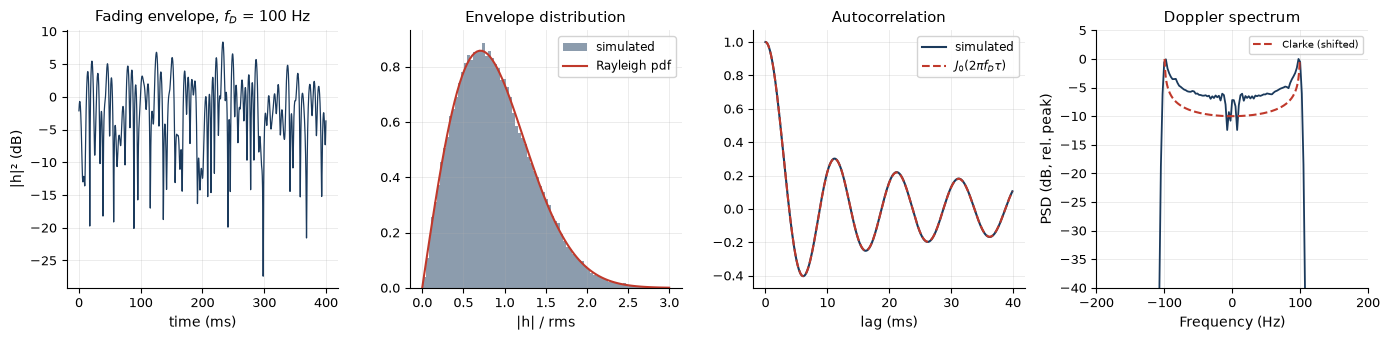

Coherence time ≈ 0.423 / f_D = 4.23 ms


In [9]:
fs = 10e3
fd = 100.0
g = cl.jakes_process(200_000, fd / fs, n_sin=32, rng=rng)
f, ax = lk.fig("row4", 1, 4)
tt = np.arange(4000) / fs
ax[0].plot(tt * 1e3, lk.db(np.abs(g[:4000]) ** 2), lw=0.9); ax[0].set_xlabel("time (ms)"); ax[0].set_ylabel("|h|² (dB)")
ax[0].set_title(f"Fading envelope, $f_D$ = {fd:.0f} Hz")
r = np.abs(g) / np.sqrt(np.mean(np.abs(g) ** 2))
x = np.linspace(0, 3, 100)
ax[1].hist(r, 80, density=True, alpha=0.5, color=lk.NAVY, label="simulated")
ax[1].plot(x, 2 * x * np.exp(-x ** 2), color=lk.RED, label="Rayleigh pdf"); ax[1].legend()
ax[1].set_title("Envelope distribution"); ax[1].set_xlabel("|h| / rms")
lags = np.arange(0, 400)
ac = np.array([np.mean(g[:-400] * np.conj(g[l:len(g) - 400 + l])) for l in lags]).real
ax[2].plot(lags / fs * 1e3, ac / ac[0], label="simulated")
ax[2].plot(lags / fs * 1e3, j0(2 * np.pi * fd * lags / fs), "--", color=lk.RED, label="$J_0(2\\pi f_D\\tau)$")
ax[2].set_xlabel("lag (ms)"); ax[2].legend(); ax[2].set_title("Autocorrelation")
lk.psd(ax[3], g, fs, 4096, color=lk.NAVY)
fr = np.linspace(-0.995 * fd, 0.995 * fd, 400)
ax[3].plot(fr, lk.db(1 / np.sqrt(1 - (fr / fd) ** 2)) - 10, color=lk.RED, ls="--", label="Clarke (shifted)")
ax[3].set_xlim(-2 * fd, 2 * fd); ax[3].set_ylim(-40, 5); ax[3].set_title("Doppler spectrum"); ax[3].legend(fontsize=7.5)
lk.show(f)
print(f"Coherence time ≈ 0.423 / f_D = {0.423 / fd * 1e3:.2f} ms")

**What you should see.** Fades of 20–30 dB lasting a fraction of a millisecond; a histogram
on the Rayleigh pdf; an autocorrelation following $J_0$ (first zero at $0.383/f_D$); and a
Doppler spectrum confined to $\pm f_D$ with horns at the edges.

### Try it yourself 2.1
A car at 120 km/h uses a 3.5 GHz NR carrier. What is the maximum Doppler shift $f_D$ in Hz?

In [11]:
answer_2_1 = None
lk.check("2.1 max Doppler at 120 km/h, 3.5 GHz", answer_2_1, 120 / 3.6 * 3.5e9 / c0, rtol=0.01)

[TODO] 2.1 max Doppler at 120 km/h, 3.5 GHz: not attempted yet: replace the None with your answer

## 3. Level crossings and fade durations

System designers need more than a pdf: *how often* does the signal drop below a threshold
$\rho$ (relative to RMS), and *for how long*? For Clarke's model (Rice's results):

$$N_R(\rho) = \sqrt{2\pi}\,f_D\,\rho\,e^{-\rho^2}\ \text{crossings/s},\qquad
\bar\tau(\rho) = \frac{e^{\rho^2}-1}{\rho f_D\sqrt{2\pi}}\ \text{s}.$$

These set interleaver depths (the code must span a fade) and HARQ timing.

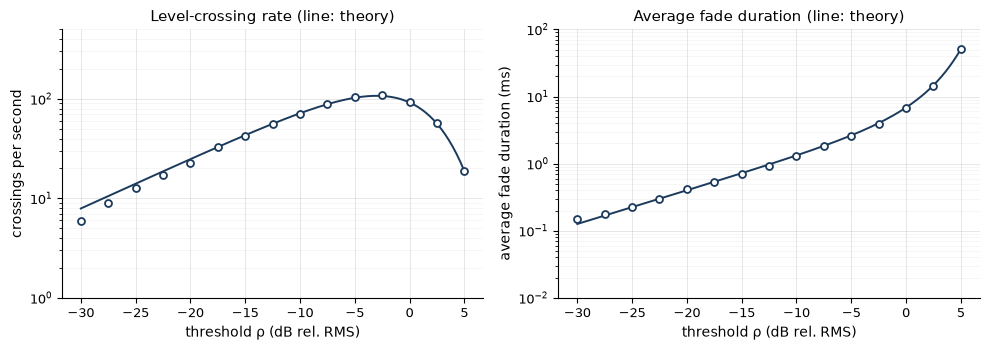

In [13]:
rho_db = np.arange(-30, 6, 2.5)
rho = 10 ** (rho_db / 20)
lcr_sim, afd_sim = [], []
T = len(r) / fs
for rr in rho:
    below = r < rr
    down = np.sum(below[1:] & ~below[:-1])
    lcr_sim.append(down / T)
    afd_sim.append(np.mean(below) / max(down / T, 1e-9))
rf = np.linspace(-30, 5, 200); rl = 10 ** (rf / 20)
f, ax = lk.fig("row2", 1, 2)
lk.ber_plot(ax[0], rho_db, {"simulated": lcr_sim}, {"simulated": np.sqrt(2 * np.pi) * fd * rl * np.exp(-rl ** 2)},
            x_theory=rf, xlabel="threshold ρ (dB rel. RMS)", ylabel="crossings per second", ylim=(1, 500), legend=False)
ax[0].set_title("Level-crossing rate (line: theory)")
lk.ber_plot(ax[1], rho_db, {"simulated": np.array(afd_sim) * 1e3},
            {"simulated": (np.exp(rl ** 2) - 1) / (rl * fd * np.sqrt(2 * np.pi)) * 1e3},
            x_theory=rf, xlabel="threshold ρ (dB rel. RMS)", ylabel="average fade duration (ms)",
            ylim=(0.01, 100), legend=False)
ax[1].set_title("Average fade duration (line: theory)")
lk.show(f)

**What you should see.** The simulation lands on Rice's formulas. The crossing rate peaks
near −3 dB at about $f_D$ crossings per second; deep fades are rare *and* short: a 20 dB
fade at $f_D$ = 100 Hz lasts on average only about 0.4 ms.

## 4. Frequency selectivity: tapped-delay-line models

The LTE extended models (3GPP TS 36.101 Annex B) remain the most used quick-look profiles:
EPA (410 ns maximum delay), EVA (2.51 µs) and ETU (5 µs). 5G NR uses the TDL-A…E and CDL
models of TR 38.901, which scale a normalised profile by a chosen RMS delay spread.

### Interactive: time–frequency channel response
The image shows $|H(f,t)|$ over a 15 MHz band. The coherence bandwidth
$B_c \approx 1/(5\tau_{\mathrm{rms}})$ sets the width of the frequency fades; the Doppler sets
how fast they move.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

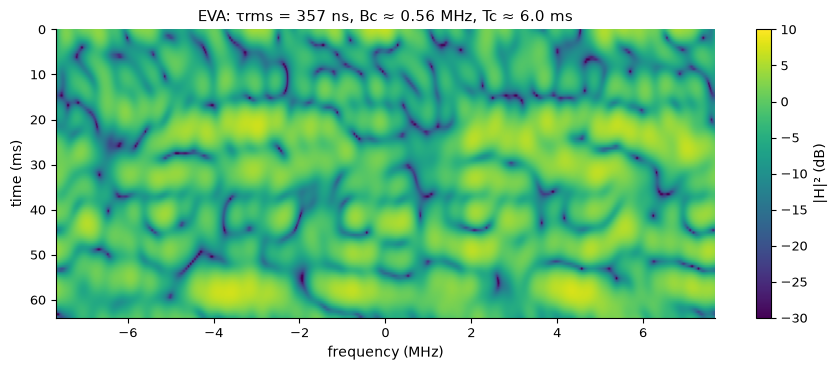

In [16]:
def rms_delay(profile):
    dl, p = cl.TDL_PROFILES[profile]
    p = 10 ** (np.array(p) / 10); p /= p.sum(); dl = np.array(dl) * 1e-9
    return np.sqrt(np.sum(p * dl ** 2) - np.sum(p * dl) ** 2)

def tf_response(profile="EVA", fd_hz=70.0):
    fs_ = 15.36e6; nfft = 1024; nsym = 120; step = 1024 * 8
    _, taps = cl.tdl_channel(np.ones(nsym * step), fs_, profile, fd_hz, rng=rng, return_taps=True)
    Ht = np.fft.fftshift(np.fft.fft(taps[::step], nfft, axis=1), axes=1)
    f, ax = lk.fig((9, 3.8))
    im = ax.imshow(lk.db(np.abs(Ht) ** 2), aspect="auto", vmin=-30, vmax=10, cmap="viridis",
                   extent=[-fs_ / 2e6, fs_ / 2e6, nsym * step / fs_ * 1e3, 0])
    tr = rms_delay(profile)
    ax.grid(False); ax.set_xlabel("frequency (MHz)"); ax.set_ylabel("time (ms)")
    ax.set_title(f"{profile}: τrms = {tr * 1e9:.0f} ns, Bc ≈ {1 / (5 * tr) / 1e6:.2f} MHz, "
                 f"Tc ≈ {0.423 / max(fd_hz, 1e-3) * 1e3:.1f} ms")
    plt.colorbar(im, ax=ax, label="|H|² (dB)")
    lk.show(f)

lk.interact(tf_response, profile=lk.choice(["EPA", "EVA", "ETU"], "EVA", "profile"),
            fd_hz=lk.slider(70, 0, 500, 5, "Doppler fD (Hz)"))

**What you should see.** Vertical stripes of fading whose width in MHz shrinks from EPA to
ETU, and that drift in time faster as $f_D$ grows. An OFDM system (Lab 7) sees each
subcarrier as flat; a single-carrier 15 MHz signal sees the whole selective mess (Lab 6).

## 5. Coherence bandwidth, measured

The frequency correlation $R_H(\Delta f) = E[H(f)H^*(f+\Delta f)]$ is the Fourier transform of
the power-delay profile. The **coherence bandwidth** is where $|R_H|$ falls to 0.5; the rule
of thumb $B_c \approx 1/(5\tau_{\text{rms}})$ is only a rule of thumb, as the table shows.

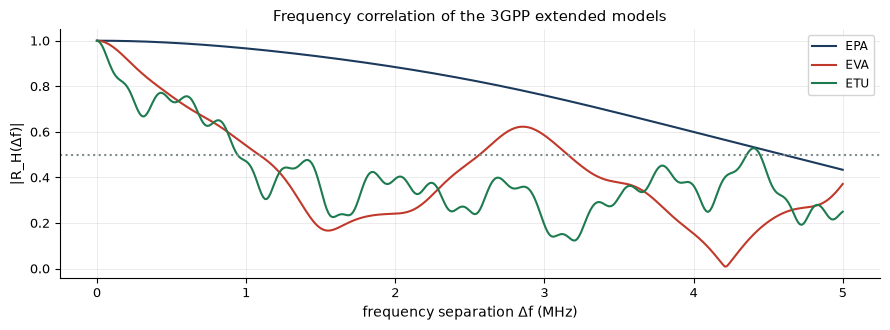

profile,τrms (ns),Bc at 0.5 (MHz),1/(5 τrms) (MHz)
EPA,43,4.61,4.64
EVA,357,1.09,0.56
ETU,991,0.95,0.20


In [19]:
dfs = np.linspace(0, 5e6, 400)
rows = []
f, ax = lk.fig("wide")
for prof, col in [("EPA", lk.NAVY), ("EVA", lk.RED), ("ETU", lk.GREEN)]:
    dl, pdb = cl.TDL_PROFILES[prof]
    p = 10 ** (np.array(pdb) / 10); p /= p.sum()
    R = np.abs(np.sum(p[None, :] * np.exp(-2j * np.pi * dfs[:, None] * np.array(dl)[None, :] * 1e-9), axis=1))
    ax.plot(dfs / 1e6, R, color=col, label=prof)
    bc = dfs[np.argmax(R < 0.5)] if np.any(R < 0.5) else np.nan
    rows.append([prof, rms_delay(prof) * 1e9, bc / 1e6, 1 / (5 * rms_delay(prof)) / 1e6])
ax.axhline(0.5, color=lk.GRAY, ls=":"); ax.set_xlabel("frequency separation Δf (MHz)")
ax.set_ylabel("|R_H(Δf)|"); ax.legend(); ax.set_title("Frequency correlation of the 3GPP extended models")
lk.show(f)
lk.table(rows, ["profile", "τrms (ns)", "Bc at 0.5 (MHz)", "1/(5 τrms) (MHz)"], fmt={1: ".0f", 2: ".2f", 3: ".2f"})

**What you should see.** EPA stays correlated over several MHz; EVA and ETU drop below 0.5
within about a megahertz, and the curves are not even monotonic. The 0.5-crossing and the
rule of thumb agree only to within a factor of about two: fine for choosing a pilot spacing,
not for a paper.

## 6. The price of fading

BPSK in flat Rayleigh fading with perfect channel knowledge:
$P_b = \frac12\left(1-\sqrt{\frac{\bar\gamma}{1+\bar\gamma}}\right)\approx \frac{1}{4\bar\gamma}$.
The error rate falls only as $1/\mathrm{SNR}$ (diversity order 1) instead of exponentially;
at $10^{-5}$ the gap to AWGN is over 30 dB. Diversity (Lab 10) and coding with interleaving
(Labs 8–9) are how systems buy it back. A line-of-sight component (Rician $K$-factor) moves
the curve toward AWGN.

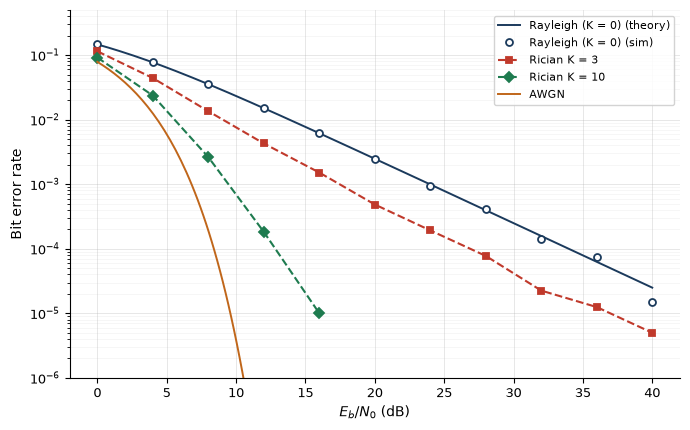

In [22]:
eb = np.arange(0, 41, 4.0)
ebf = np.linspace(0, 40, 200)
bits = cl.random_bits(400_000, rng)
xb = 1 - 2 * bits.astype(float)
sims = {}
for K in [0, 3, 10]:
    los, nlos = np.sqrt(K / (K + 1)), np.sqrt(1 / (K + 1))
    hch = los + nlos * (rng.standard_normal(len(xb)) + 1j * rng.standard_normal(len(xb))) / np.sqrt(2)
    ber = []
    for e in eb:
        n0 = 10 ** (-e / 10)
        y = hch * xb + np.sqrt(n0 / 2) * (rng.standard_normal(len(xb)) + 1j * rng.standard_normal(len(xb)))
        ber.append(np.mean((np.real(np.conj(hch) * y) < 0) != bits))
    sims["Rayleigh (K = 0)" if K == 0 else f"Rician K = {K}"] = ber
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb, sims, {"Rayleigh (K = 0)": cl.ber_bpsk_rayleigh(ebf), "AWGN": cl.ber_bpsk(ebf)}, x_theory=ebf)
lk.show(f)

**What you should see.** The Rayleigh simulation on its theory line with a slope of one decade
per 10 dB; AWGN plunging vertically; Rician curves in between, steeper as $K$ grows.

### Try it yourself 6.1
Using the approximation $P_b \approx 1/(4\bar\gamma)$, what average $E_b/N_0$ (dB) does BPSK
need in Rayleigh fading for $P_b = 10^{-5}$?

In [24]:
answer_6_1 = None
lk.check("6.1 Rayleigh Eb/N0 for 1e-5", answer_6_1, lk.db(1 / (4e-5)), atol=0.2)

[TODO] 6.1 Rayleigh Eb/N0 for 1e-5: not attempted yet: replace the None with your answer

## 7. Channel sounding by correlation

Transmit a sequence with an impulse-like periodic autocorrelation (Zadoff–Chu, m-sequence)
and cross-correlate: the result is the channel impulse response. Averaging over periods buys
SNR. This is exactly what `gnuradio/gr03_channel_sounder.py` does over the air, and the same
processing reads its recordings.

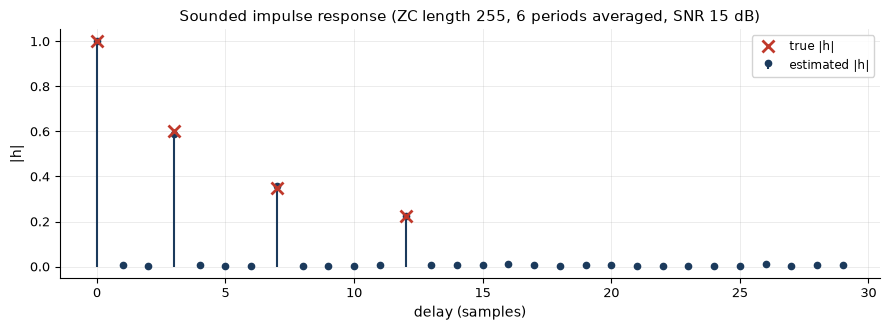

In [26]:
N = 255
zc = cl.zadoff_chu(1, N)
tx = np.tile(zc, 8)
hch = np.zeros(20, complex); hch[[0, 3, 7, 12]] = [1, 0.6j, -0.35, 0.2 + 0.1j]
rx = cl.awgn(np.convolve(tx, hch)[:len(tx)], 15, rng)
seg = rx[N:N * 7].reshape(6, N).mean(axis=0)         # skip the first (transient) period, average 6
cir = np.fft.ifft(np.fft.fft(seg) * np.conj(np.fft.fft(zc))) / N
f, ax = lk.fig("wide")
ax.stem(np.arange(30), np.abs(cir[:30]), basefmt=" ", label="estimated |h|")
nz = np.flatnonzero(hch)
ax.plot(nz, np.abs(hch[nz]), "x", color=lk.RED, ms=9, mew=2, label="true |h|")
ax.legend(); ax.set_xlabel("delay (samples)"); ax.set_ylabel("|h|")
ax.set_title("Sounded impulse response (ZC length 255, 6 periods averaged, SNR 15 dB)")
lk.show(f)

## Key takeaways
* Three scales: path loss (tens of dB per decade), shadowing (±σ dB, log-normal), fast fading
  (Rayleigh: 20 dB fades 1% of the time).
* Doppler $f_D = v f_c/c$ sets coherence time ($\approx 0.423/f_D$), crossing rates and fade durations.
* Delay spread sets coherence bandwidth ($\sim 1/(5\tau_{\text{rms}})$); wideband signals see
  frequency-selective fading.
* Without diversity, fading turns exponential error curves into $1/\mathrm{SNR}$.

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr03_channel_sounder.py --sim --multipath` measures the power-delay profile and
  RMS delay spread; with hardware, walk down a hallway with the RX antenna and watch the
  taps fade and the delay spread change.
* Record the received power of a steady carrier from gr01 while moving, and plot its
  histogram and level-crossing rate against Section 3.

## Exercises
1. **(Warm-up)** Compute τrms for EPA, EVA and ETU by hand and confirm the table in Section 5.
2. **(Core)** For an NR carrier at 3.5 GHz with 30 kHz subcarrier spacing, what UE speed
   makes the Doppler 5% of the subcarrier spacing? Why is that a useful threshold (Lab 7)?
3. **(Core)** Estimate the Rician K-factor from simulated envelope samples with the moment
   method $K = \sqrt{1-\gamma}/(1-\sqrt{1-\gamma})$, $\gamma = \mathrm{Var}(|h|^2)/E[|h|^2]^2$.
4. **(Core)** Implement the TR 38.901 UMa LOS/NLOS path-loss formulas and compare them with
   the log-distance model at 3.5 GHz.
5. **(Stretch)** Record a sounder capture with gr03 while walking, then estimate the
   power-delay profile, τrms and the Doppler spectrum of each tap.

In [28]:
lk.summary()

[good] Lab 05 finished in 8.6 s. Self-checks: 0 passed, 0 failed, 3 still to do.